# 000978 stage 2 — linear baselines (PCA / dPCA / GPFA)

Artifacts from `src/000978/02_baseline_linear.py`, computed on **run** epochs
(the awake W-track manifold). CA1 and PFC kept separate.

1. **PCA** — scree + scores coloured by run session (does activity drift across
   the day?)
2. **dPCA** — variance split into **space / session / interaction**; the session
   and interaction terms are the learning signal
3. **GPFA** — latent trajectory per run session

Run `pixi run python src/000978/02_baseline_linear.py` first if artifacts are missing.


## Setup

In [1]:
import sys, pathlib
_root = next(p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]
             if (p / "src" / "common" / "config.py").exists())
for _d in ("common", "000978"):
    sys.path.insert(0, str(_root / "src" / _d))
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from config import processed_dir, BIN_SIZE_S
DATA_PROCESSED = processed_dir("000978")
BIN_MS = int(BIN_SIZE_S * 1000)
plt.rcParams["figure.dpi"] = 100

## 1. PCA — variance and scores by run session

0 pca_ER1_CA1_1000ms.npz
1 pca_ER1_PFC_1000ms.npz
2 pca_JS14_CA1_1000ms.npz
3 pca_JS14_PFC_1000ms.npz
4 pca_JS15_CA1_1000ms.npz
5 pca_JS15_PFC_1000ms.npz
6 pca_JS17_CA1_1000ms.npz
7 pca_JS17_PFC_1000ms.npz
8 pca_JS21_CA1_1000ms.npz
9 pca_JS21_PFC_1000ms.npz
10 pca_JS34_CA1_1000ms.npz
11 pca_JS34_PFC_1000ms.npz
12 pca_KL8_CA1_1000ms.npz
13 pca_KL8_PFC_1000ms.npz
14 pca_ZT2_obj-1dss6zi_CA1_1000ms.npz
15 pca_ZT2_obj-1dss6zi_PFC_1000ms.npz
16 pca_ZT2_obj-u40err_CA1_1000ms.npz
17 pca_ZT2_obj-u40err_PFC_1000ms.npz


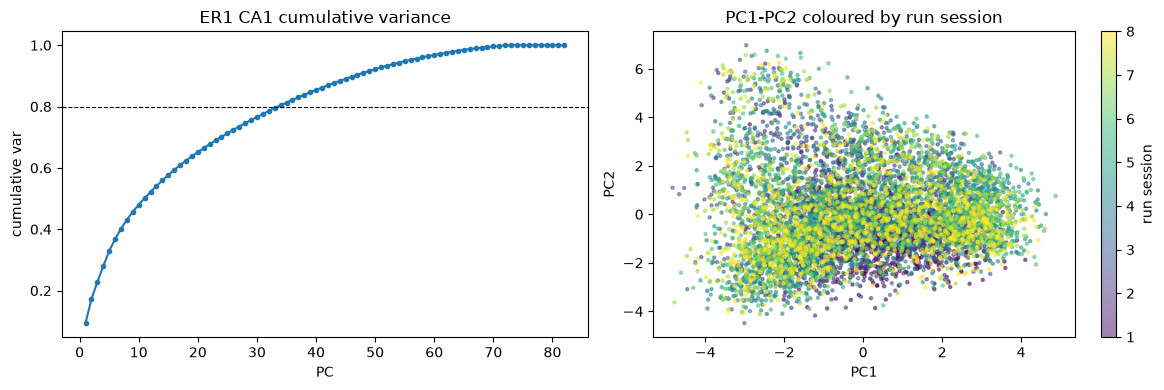

In [2]:
pca_files = sorted(DATA_PROCESSED.glob(f"pca_*_{BIN_MS}ms.npz"))
for i, f in enumerate(pca_files): print(i, f.name)
p = np.load(pca_files[0], allow_pickle=False)
session, region = str(p["session_key"]), str(p["region"])
evr, scores, rs = p["explained_variance_ratio"], p["scores"], p["run_session"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(np.arange(1, len(evr) + 1), np.cumsum(evr), "o-", ms=3)
axes[0].axhline(0.8, color="k", ls="--", lw=0.8)
axes[0].set_xlabel("PC"); axes[0].set_ylabel("cumulative var")
axes[0].set_title(f"{session} {region} cumulative variance")
sc = axes[1].scatter(scores[:, 0], scores[:, 1], c=rs, cmap="viridis", s=5, alpha=0.5)
axes[1].set_xlabel("PC1"); axes[1].set_ylabel("PC2")
axes[1].set_title("PC1-PC2 coloured by run session")
fig.colorbar(sc, ax=axes[1], label="run session")
plt.tight_layout()

## 2. dPCA — space / session / interaction across animals

Fraction of run-epoch variance carried by components depending on **space**
(stable map), **session** (global drift across learning), and their
**interaction** (the map reshaping session-to-session).

,space,session_var,interact
region,,,
CA1,0.477,0.165,0.128
PFC,0.494,0.178,0.123


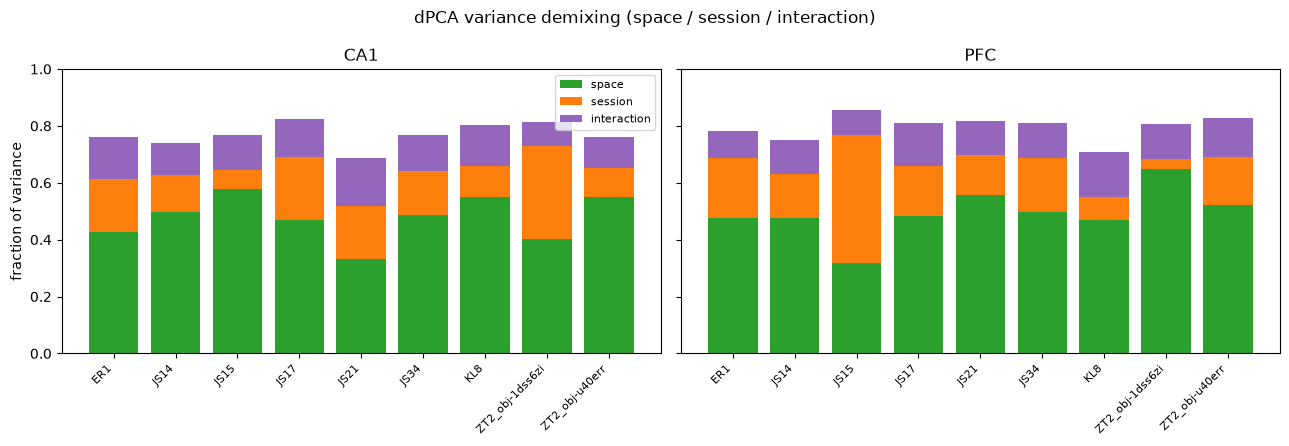

In [3]:
rows = []
for f in sorted(DATA_PROCESSED.glob(f"dpca_*_{BIN_MS}ms.npz")):
    d = np.load(f, allow_pickle=False)
    rows.append((str(d["session_key"]), str(d["region"]),
                 float(d["evr_s"].sum()), float(d["evr_q"].sum()), float(d["evr_sq"].sum()),
                 int(d["sessions"].size)))
df = pd.DataFrame(rows, columns=["session", "region", "space", "session_var", "interact", "n_sess"])

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)
for ax, region in zip(axes, ["CA1", "PFC"]):
    sub = df[df.region == region].set_index("session")
    x = np.arange(len(sub))
    ax.bar(x, sub.space, label="space", color="tab:green")
    ax.bar(x, sub.session_var, bottom=sub.space, label="session", color="tab:orange")
    ax.bar(x, sub.interact, bottom=sub.space + sub.session_var, label="interaction", color="tab:purple")
    ax.set_xticks(x); ax.set_xticklabels(sub.index, rotation=45, ha="right", fontsize=8)
    ax.set_title(region); ax.set_ylim(0, 1)
axes[0].set_ylabel("fraction of variance"); axes[0].legend(loc="upper right", fontsize=8)
fig.suptitle("dPCA variance demixing (space / session / interaction)")
plt.tight_layout()
df.groupby("region")[["space", "session_var", "interact"]].mean().round(3)

## 3. GPFA — latent trajectory per run session
Mean latent trajectory (first 3 dims), coloured session 1→N.

0 gpfa_ER1_CA1.npz
1 gpfa_ER1_PFC.npz
2 gpfa_JS14_CA1.npz
3 gpfa_JS14_PFC.npz
4 gpfa_JS15_CA1.npz
5 gpfa_JS15_PFC.npz
6 gpfa_JS17_CA1.npz
7 gpfa_JS17_PFC.npz
8 gpfa_JS21_CA1.npz
9 gpfa_JS21_PFC.npz
10 gpfa_JS34_CA1.npz
11 gpfa_JS34_PFC.npz
12 gpfa_KL8_CA1.npz
13 gpfa_KL8_PFC.npz
14 gpfa_ZT2_obj-1dss6zi_CA1.npz
15 gpfa_ZT2_obj-1dss6zi_PFC.npz
16 gpfa_ZT2_obj-u40err_CA1.npz
17 gpfa_ZT2_obj-u40err_PFC.npz


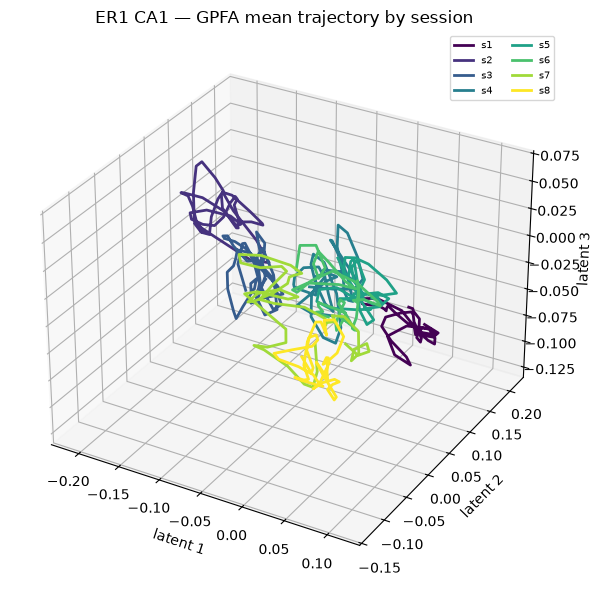

In [4]:
gpfa_files = sorted(DATA_PROCESSED.glob("gpfa_*.npz"))
if not gpfa_files:
    print("no GPFA artifacts yet — still running? run: python src/000978/02_baseline_linear.py --method gpfa")
else:
    for i, f in enumerate(gpfa_files): print(i, f.name)
    g = np.load(gpfa_files[0], allow_pickle=False)
    lat, tsess = g["latents"], g["trial_run_session"]
    session, region = str(g["session_key"]), str(g["region"])
    sessions = sorted(np.unique(tsess).tolist())
    cmap = plt.cm.viridis
    fig = plt.figure(figsize=(6, 6)); ax = fig.add_subplot(111, projection="3d")
    for k, s in enumerate(sessions):
        mt = lat[tsess == s].mean(axis=0)
        ax.plot(mt[0], mt[1], mt[2], color=cmap(k / max(len(sessions) - 1, 1)), lw=2, label=f"s{s}")
    ax.set_xlabel("latent 1"); ax.set_ylabel("latent 2"); ax.set_zlabel("latent 3")
    ax.legend(fontsize=7, ncol=2); ax.set_title(f"{session} {region} — GPFA mean trajectory by session")
    plt.tight_layout()

---
**Next:** stage 3 (CEBRA/UMAP/Isomap) on 000978 run epochs, then the
000978-specific 6b (session-sequence alignment — quantify drift vs. session
number) and 6c (project sleep epochs into the awake manifold). ZT2's two files
need their run sessions stitched into a global 1-8 order first.